EXPLORATORY DATA ANALYSIS

Preliminary dataset analysis:

-dataset overview and class distribution
-texts length
-vocabulary structure 
-frequent words and bigrams
-presence of numbers and symbols

In [2]:
#0) setup

from pathlib import Path
from collections import Counter    
import re
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import wordpunct_tokenize
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_colwidth", 120)


DATA_PATH = Path("../data/Sentences_50Agree.txt")
OUTPUT_DIR = Path("../results/task1_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


rows = []

with open(DATA_PATH, "r", encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if line:
            text, label = line.rsplit("@", 1)
            rows.append({"text": text.strip(), "label": label.strip()})

df = pd.DataFrame(rows)

print("Dataset loaded successfully.")
print("Number of examples:", len(df))
print("Labels:", sorted(df["label"].unique()))

df.head()

Dataset loaded successfully.
Number of examples: 4846
Labels: ['negative', 'neutral', 'positive']


,text,label
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i...",neutral
1,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies work...",neutral
2,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; con...,negative
3,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...,positive
4,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth ...",positive


In [3]:
#1) dataset overview and class distribution

class_distribution = df["label"].value_counts().reset_index()
class_distribution.columns = ["label", "count"]
class_distribution["percentage"] = (class_distribution["count"] / len(df) * 100).round(2)

overview = pd.DataFrame({
    "Property": [
        "Number of headlines",
        "Neutral headlines",
        "Positive headlines",
        "Negative headlines"
    ],
    "Value": [
        len(df),
        int(class_distribution.loc[class_distribution["label"] == "neutral", "count"].iloc[0]),
        int(class_distribution.loc[class_distribution["label"] == "positive", "count"].iloc[0]),
        int(class_distribution.loc[class_distribution["label"] == "negative", "count"].iloc[0])
    ]
})

overview

,Property,Value
0,Number of headlines,4846
1,Neutral headlines,2879
2,Positive headlines,1363
3,Negative headlines,604


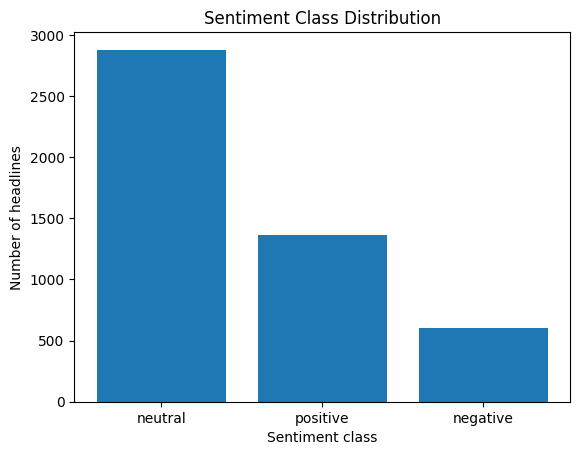

In [4]:

plt.figure()
plt.bar(class_distribution["label"], class_distribution["count"])
plt.xlabel("Sentiment class")
plt.ylabel("Number of headlines")
plt.title("Sentiment Class Distribution")
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=300)
plt.show()

In [5]:
#2) texts length analysis

df["tokens"] = df["text"].str.lower().apply(wordpunct_tokenize)
df["text_length"] = df["tokens"].apply(len)

length_stats = df["text_length"].describe().round(2)
length_stats

count    4846.00
mean       25.10
std        11.13
min         2.00
25%        17.00
50%        23.00
75%        32.00
max       100.00
Name: text_length, dtype: float64

In [6]:
# Text length by class
length_by_class = (
    df.groupby("label")["text_length"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

length_by_class

,count,mean,median,min,max
label,,,,,
negative,604,27.00,25.0,5,61
neutral,2879,23.79,22.0,2,100
positive,1363,27.04,25.0,5,63


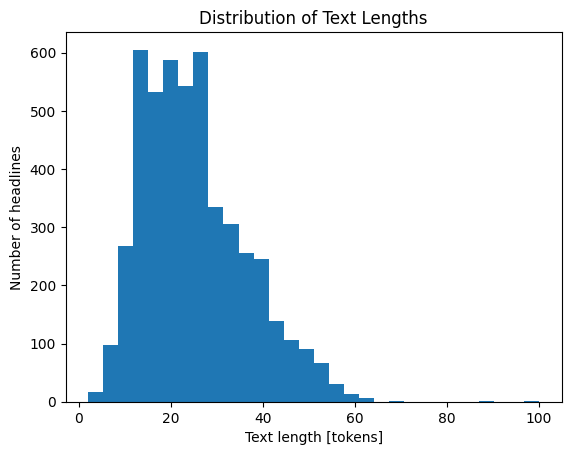

In [7]:
plt.figure()
plt.hist(df["text_length"], bins=30)
plt.xlabel("Text length [tokens]")
plt.ylabel("Number of headlines")
plt.title("Distribution of Text Lengths")
plt.savefig(OUTPUT_DIR / "text_length_distribution.png", dpi=300)
plt.show()

In [8]:
#3) vocabulary analysis

all_tokens = [token for tokens in df["tokens"] for token in tokens]

total_tokens = len(all_tokens)
vocab_size = len(set(all_tokens))
unique = sum(1 for token in set(all_tokens) if all_tokens.count(token) == 1)
type_token_ratio = vocab_size / total_tokens * 100

vocab_stats = pd.DataFrame({
    "Property": [
        "Total tokens",
        "Vocabulary size",
        "Type-token ratio (%)",
        "Unique tokens"
    ],
    "Value": [
        total_tokens,
        vocab_size,
        round(type_token_ratio, 2),
        unique
    ]
})

vocab_stats

,Property,Value
0,Total tokens,121652.00
1,Vocabulary size,10151.00
2,Type-token ratio (%),8.34
3,Unique tokens,5120.00


In [9]:
#4) frequent words

word_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english"
)

word_matrix = word_vectorizer.fit_transform(df["text"])
word_frequencies = word_matrix.sum(axis=0).A1

top_words = pd.DataFrame({
    "word": word_vectorizer.get_feature_names_out(),
    "frequency": word_frequencies
}).sort_values("frequency", ascending=False)

top_words.head(20)

,word,frequency
3240,eur,1017
2150,company,851
7714,said,545
3708,finnish,524
5826,mn,515
7727,sales,455
5783,million,440
6040,net,413
6963,profit,410
9730,year,395


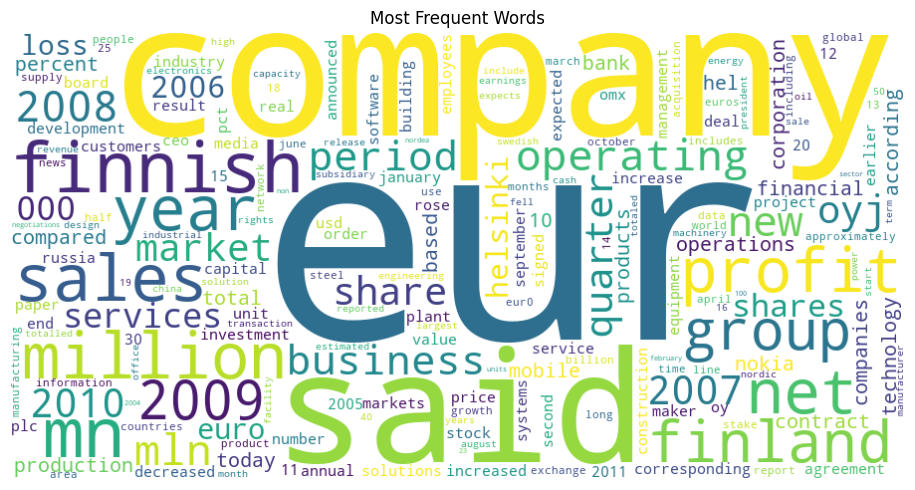

In [10]:
from wordcloud import WordCloud

word_frequencies = dict(zip(top_words["word"], top_words["frequency"]))

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate_from_frequencies(word_frequencies)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordcloud_content_words.png", dpi=300)
plt.show()

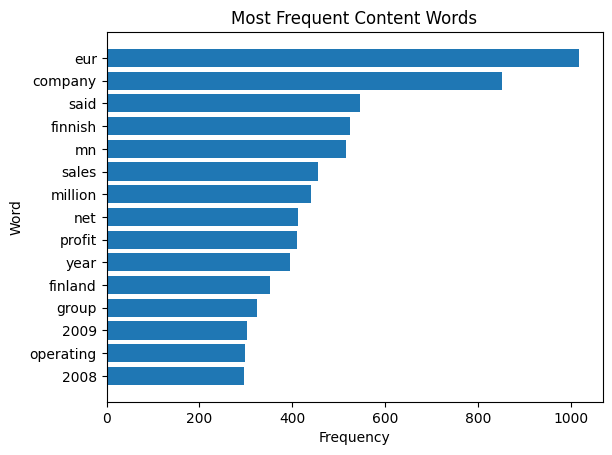

In [11]:
plot_data = top_words.head(15).iloc[::-1]

plt.figure()
plt.barh(plot_data["word"], plot_data["frequency"])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Most Frequent Content Words")
plt.savefig(OUTPUT_DIR / "top_content_words.png", dpi=300)
plt.show()

In [13]:
#5) frequent bigrams

bigram_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(2, 2)
)

bigram_matrix = bigram_vectorizer.fit_transform(df["text"])
bigram_frequencies = bigram_matrix.sum(axis=0).A1

top_bigrams = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "frequency": bigram_frequencies
}).sort_values("frequency", ascending=False)

top_bigrams.head(20)

,bigram,frequency
24904,net sales,246
14050,eur mn,196
26261,operating profit,194
24206,mn eur,127
10219,corresponding period,108
24140,mln euro,107
24903,net profit,93
32767,said today,86
27016,oyj hel,85
8982,company said,73


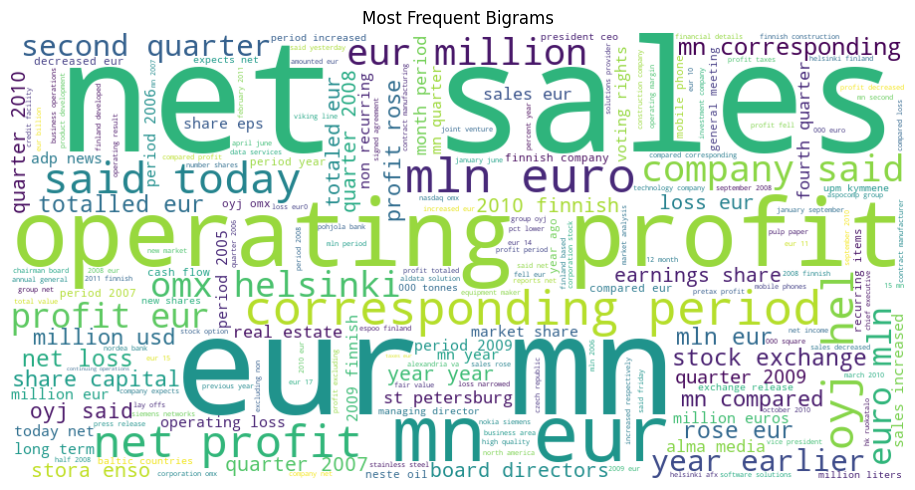

In [14]:
from wordcloud import WordCloud

word_frequencies = dict(zip(top_bigrams["bigram"], top_bigrams["frequency"]))

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate_from_frequencies(word_frequencies)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Bigrams")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordcloud_bigrams.png", dpi=300)
plt.show()

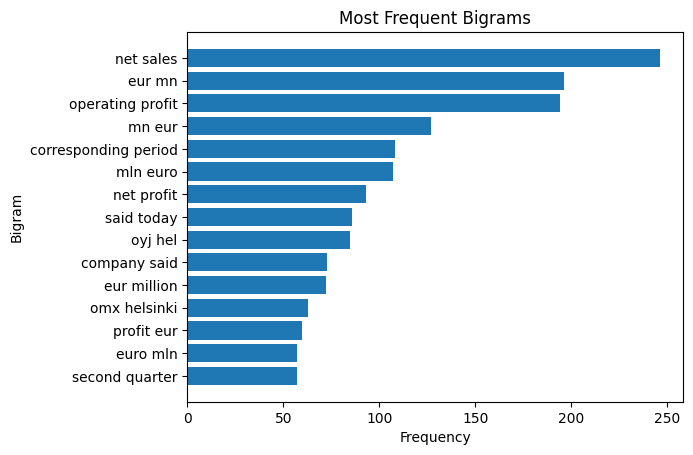

In [15]:
plot_data = top_bigrams.head(15).iloc[::-1]

plt.figure()
plt.barh(plot_data["bigram"], plot_data["frequency"])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Most Frequent Bigrams")
plt.savefig(OUTPUT_DIR / "top_bigrams.png", dpi=300)
plt.show()

In [16]:
#6) numbers, percentages, money

df["contains_number"] = df["text"].str.contains(r"\d", regex=True)
df["contains_percentage"] = df["text"].str.contains(r"\d+(?:[.,]\d+)?\s*%", regex=True)
df["contains_money"] = df["text"].str.lower().str.contains(
    r"\b(eur|euro|usd|dollar|mn|mln|million|billion|bn)\b|[$€]",
    regex=True
)

numeric_summary = pd.DataFrame({
    "feature": ["contains_number", "contains_percentage", "contains_money"],
    "count": [
        df["contains_number"].sum(),
        df["contains_percentage"].sum(),
        df["contains_money"].sum()
    ]
})

numeric_summary["percentage"] = (
    numeric_summary["count"] / len(df) * 100
).round(2)

numeric_summary

C:\Users\tella\AppData\Local\Temp\ipykernel_7908\889358839.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["contains_money"] = df["text"].str.lower().str.contains(


,feature,count,percentage
0,contains_number,2584,53.32
1,contains_percentage,328,6.77
2,contains_money,958,19.77


In [17]:
numeric_by_class = (
    df.groupby("label")[["contains_number", "contains_percentage", "contains_money"]]
    .mean()
    .mul(100)
    .round(2)
)

numeric_by_class

,contains_number,contains_percentage,contains_money
label,,,
negative,75.33,12.09,38.74
neutral,46.65,4.13,12.40
positive,57.67,9.98,26.93
